# Fine-Tuned Person Re-Identification on PRW

End-to-end person search on the PRW dataset.

**Dataset**: contains 932 identities and 11,816 frames acquired through six cameras, in which pedestrians are annotated with their bounding box positions and identities.

**Task**: given a query crop of a person, find that same person across whole-scene gallery frames.

**Pipeline**: detect every person in the gallery frames, encode each crop with a fine-tuned DINOv3, and rank detections by cosine similarity to the query embedding.

**Foundational idea**: given the state of the art of open-source model (yolo, rfdetr, sam, dino, etc. are all open-source!), this solution heavily rely on such models to tackle the whole pipeline; detectors (first stage of person-search) will be used as zero-shot person detectors, without custom architectures or useless training.  
Unlike a pure zero-shot person search (this notebook's sibling in the same repo), the feature embedder is **fine-tuned** with metric learning on PRW training crops, so its embeddings separate identities rather than generic object categories.
We employ this separation (detection vs re-identification) as they're different problems that can be optimized separately:
- Detectors' visual backbones are optimized for localization and classification (`person` here, `car` there, etc.) 
- Re-ID backbones can be optimized through metric learning to push closer/further embeddings beloning to the same category (`same` person, `different` persons).

**Key choices**: 
- Yolov12 and RF-DETR off-the-shelf detectors; 
- DINOv3 ViT-L/16 backbone with the last N transformer blocks unfrozen and a BNNeck projection head; 
- ArcFace, Triplet, NT-Xent metric-learning losses.

**Configurations**: define the ablation to perform to assess the performance of the whole pipeline (`PERSONSEARCH_CONFIGS`, summarized in the table below).

| Config | Detector | Re-ID loss |
|--------|----------|------------|
| A | YOLOv12 | ArcFace |
| B | YOLOv12 | TripletMargin |
| C | YOLOv12 | NT-Xent |
| D | RF-DETR | ArcFace |
| E | RF-DETR | TripletMargin |
| F | RF-DETR | NT-Xent |

**AI Usage and sources**: as being an AI student in the explosion of AI era, where even a simple google search returns a code snippet written by google AI overview, is needless to say that AI have been used for realizing the notebook. AI must (and has been) be used as a learning and empowering tool, and never as a shortcut.  
None of the implementation choices have been made by AI.  

Main AI usage regards:
- Understand the interface of `eval_search_prw()`;
- Understand the `.m` files exposed by the dataset;
- Translate `generate_query.m` in `generate_query_train.py`;
- Build plot functions;
- Debug code for errors and buggy behaviors (the biggest help!);
- Docstrings and markdown generation, with heavy "human" integration.  

All the relevant sources (including AI tools) are listed in the docstrings of related code blocks.


# 0. Setup!

Import useful packages, define configuration runs, download and extract the dataset.

## 0.1 Import packages
All the packages are defined here, while custom functions and classes are defined throughout the notebook.

In [1]:
import os
import re
import sys
import json
import warnings
import zipfile
from pathlib import Path
from typing import Optional

import numpy as np
from scipy.io import loadmat
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import random
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms as T

from ultralytics import YOLO
from rfdetr import RFDETRBase
from transformers import AutoImageProcessor, AutoModel
from pytorch_metric_learning import losses, miners
from pytorch_metric_learning.samplers import MPerClassSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

sys.path.insert(0, str(Path('.').resolve()))
from utils.eval_function import eval_search_prw

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

/home/leonardo/github/person-search/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
def set_seed(seed):
    """
    Enable determinism to reproduce results.

    sources:
    - https://stackoverflow.com/q/56354461 (Bram Vanroy, License - CC BY-SA 4.0)
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

## 0.2 Define Paths and Config
Dataset and Cache paths are defined ahead, and configuration dictionaries are created to specify the ablations to perform.  
This is a very easy way to extend and add experiments as the code develops.

In [3]:
# dataset paths and urls
DATASET_ROOT = "dataset"
ZIP="prw-person-re-identification-in-the-wild.zip"
URL="https://www.kaggle.com/api/v1/datasets/download/edoardomerli/prw-person-re-identification-in-the-wild"
TRAIN_CROPS_DIR = Path(f"{DATASET_ROOT}/query_box_train") # training crops for re-id finetuning

# cache directories; useful to store detections and embeddings without rerun
CACHE_DIR = Path(f"finetune_cache")
CACHE_DIR.mkdir(exist_ok=True)

DETECTOR_DIR = Path(f"detectors")
DETECTOR_DIR.mkdir(exist_ok=True)

# configurations, easy to define and extend multiple experiments
DETECTOR_CONFIGS = {
    "yolo12": {"detector": "yolo12", "threshold": 0.3},
    "rfdetr": {"detector": "rfdetr", "threshold": 0.5},
}

REID_CONFIGS = {
    "arcface": {"encoder": "dinov3", "loss": "arcface", "embed_dim" : 1024},
    "triplet": {"encoder": "dinov3", "loss": "triplet", "embed_dim" : 1024},
    "ntxent": {"encoder": "dinov3", "loss": "ntxent", "embed_dim" : 1024},
}

PERSONSEARCH_CONFIGS = {
    "A": {**DETECTOR_CONFIGS["yolo12"], **REID_CONFIGS["arcface"]},
    "B": {**DETECTOR_CONFIGS["yolo12"], **REID_CONFIGS["triplet"]},
    "C": {**DETECTOR_CONFIGS["yolo12"], **REID_CONFIGS["ntxent"]},
    "D": {**DETECTOR_CONFIGS["rfdetr"], **REID_CONFIGS["arcface"]},
    "E": {**DETECTOR_CONFIGS["rfdetr"], **REID_CONFIGS["triplet"]},
    "F": {**DETECTOR_CONFIGS["rfdetr"], **REID_CONFIGS["ntxent"]},
}

## 0.3 Download and extract the dataset

Fetch the PRW dataset archive from Kaggle and extract it into `dataset/`. Both steps are skipped when the data is already present.

In [4]:
# check if dataset exists already
if Path(DATASET_ROOT).exists() and any(Path(DATASET_ROOT).iterdir()):
    print(f"{DATASET_ROOT} already exists and is non-empty - skipping download.")

elif Path(ZIP).exists():
    print(f"'{ZIP}' already downloaded - skipping download.")

# otw download
else:
    print(f"Downloading dataset to ./{ZIP} ...")
    !curl -L -o {ZIP} {URL}
    print("Download complete.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2734M  100 2734M    0     0  3070k      0  0:15:11  0:15:11 --:--:-- 3053k0:14:55  0:00:37  0:14:18 3080k0  0:14:56  0:00:39  0:14:17 3089k   0  0:15:06  0:02:34  0:12:32 3075k075k   0  0:15:08  0:06:01  0:09:07 3076k  0:06:29  0:08:40 3072k  0:15:09  0:07:07  0:08:02 3062k0:07:06 3069k3:02 3035k
Download complete.


In [5]:
# extract the downloaded zip. skip extraction if exists already
if os.path.isdir(DATASET_ROOT) and os.listdir(DATASET_ROOT):
    print(f"'{DATASET_ROOT}/' already exists and is non-empty - skipping extraction.")
else:
    os.makedirs(DATASET_ROOT, exist_ok=True)
    print(f"Extracting {ZIP} into {DATASET_ROOT}/ ...")
    with zipfile.ZipFile(ZIP, "r") as zip_ref:
        zip_ref.extractall(DATASET_ROOT)
    print("Extraction complete.")

Extracting prw-person-re-identification-in-the-wild.zip into dataset/ ...


Extraction complete.


## 0.4 Generate training query boxes for Re-ID finetuning

`generate_query_train.py` crops every labelled person from the training frames into `dataset/query_box_train/`. Each crop is named `NNN_frame.jpg`, where the 3-digit prefix is the person id.  

These crops are what the encoder is fine-tuned on.  

If run with `--sample` option, it generates 1374 crops (max 3 crops per train id).  
If run without `--sample` option, it generates 14,897 crops (no limit).

In [6]:
%%bash
# generates training query boxes by calling generate_query_train.py
uv run generate_query_train.py

Saved: dataset/query_box_train/001_c1s1_001051.jpg
Saved: dataset/query_box_train/001_c1s1_001351.jpg
Saved: dataset/query_box_train/001_c1s1_001376.jpg
Saved: dataset/query_box_train/001_c1s1_001526.jpg
Saved: dataset/query_box_train/001_c1s1_001726.jpg
Saved: dataset/query_box_train/001_c1s1_001751.jpg
Saved: dataset/query_box_train/001_c1s1_001851.jpg
Saved: dataset/query_box_train/001_c1s1_001901.jpg
Saved: dataset/query_box_train/001_c1s1_001926.jpg
Saved: dataset/query_box_train/001_c1s1_002301.jpg
Saved: dataset/query_box_train/001_c1s1_002326.jpg
Saved: dataset/query_box_train/001_c1s1_002351.jpg
Saved: dataset/query_box_train/001_c1s1_002376.jpg
Saved: dataset/query_box_train/001_c1s1_002401.jpg
Saved: dataset/query_box_train/001_c1s1_009376.jpg
Saved: dataset/query_box_train/001_c1s1_009451.jpg
Saved: dataset/query_box_train/001_c1s1_009476.jpg
Saved: dataset/query_box_train/001_c1s1_009526.jpg
Saved: dataset/query_box_train/001_c1s1_014601.jpg
Saved: dataset/query_box_train/

# 1. Detection!

First stage of the pipeline: locate every person in each gallery frame.

## 1.1 Dataset

`PRWDetectorDataset` wraps a gallery or query split of PRW.

- **Gallery**: whole-scene frames; person boxes come from the per-frame `.mat` annotations.
- **Query**: one labelled person per entry, read from `query_info.txt` (test) or `query_info_train.txt` (train).

Annotation boxes are stored as `[x, y, w, h]` and converted to `[x1, y1, x2, y2]` to match the detector output.  

This detection stage loads the **train** split.


In [7]:
class PRWDetectorDataset:
    """
    Detector dataset.
    Wraps either the gallery or query split of PRW. 

    annotations : list[dict]
        - img_name  (str)          — bare filename; for queries this is the SOURCE frame
        - cam_id    (int)          — camera 1-6
        - pids      (ndarray|int)  — [N] int32 array (gallery) or scalar int (query)
        - boxes     (ndarray)      — [N,4] float32 in x1,y1,x2,y2
    img_prefix : str  — directory containing the images
    is_query   : bool — when True, get_image_path reconstructs the crop filename
    split      : str  — identifies the split of the dataset.
    """

    def __init__(self, annotations: list, img_prefix: str, is_query: bool = False, split: str = 'test') -> None:
        self.annotations = annotations
        self.img_prefix = img_prefix
        self.is_query = is_query
        self.split = split

    def __len__(self) -> int:
        return len(self.annotations)

    def get_image_path(self, idx: int) -> str:
        ann = self.annotations[idx]
        if self.is_query:
            frame_base = ann["img_name"].rsplit(".", 1)[0]
            id_frame_prefix = f"{(3 - len(str(ann["pids"]))) * "0"}{ann["pids"]}"
            return os.path.join(self.img_prefix, f"{id_frame_prefix}_{frame_base}.jpg")
        return os.path.join(self.img_prefix, ann["img_name"])

In [8]:
def _cam_id_from_name(name: str) -> int:
    m = re.search(r"c(\d+)", name)
    return int(m.group(1))


def _xywh_to_xyxy(x: float, y: float, w: float, h: float) -> list:
    # convert bounding box format since detectors output in xyxy format
    return [x, y, x + w, y + h]


def build_gallery_dataset(dataset_root: str = "dataset", split: str = "test") -> PRWDetectorDataset:
    """
    Build gallery PRWDetectorDataset from the split frames.
    """
    root = Path(dataset_root)
    split_str = split
    split_arr = loadmat(str(root / f"frame_{split_str}.mat"))[f"img_index_{split_str}"].ravel()
    split_names = [x.item() for x in split_arr]   # names wo extension

    ann_dir = root / "annotations"
    annotations = []
    for name in tqdm(split_names, desc="Loading gallery annotations"):
        mat = loadmat(str(ann_dir / f"{name}.jpg.mat"))
        box_new = mat.get("box_new", # [N, 5]: pid, x, y, w, h
                          mat.get("anno_file",
                            mat.get("anno_previous", None))) # argg there exist different names

        pids = box_new[:, 0].astype(np.int32)
        boxes = np.array(
            [np.array(_xywh_to_xyxy(*box[1:]), dtype=np.float32) for box in box_new]
        ).astype(np.float32)

        annotations.append({
            "img_name": f"{name}.jpg",
            "cam_id": _cam_id_from_name(name),
            "pids": pids,
            "boxes": boxes,
        })

    return PRWDetectorDataset(annotations, str((root / "frames").resolve()), is_query=False, split=split)


def build_query_dataset(dataset_root: str = "dataset", split: str = "test") -> PRWDetectorDataset:
    """
    Build query PRWDetectorDataset from query_info_train.txt/query_info.txt.
    Line format: pid x y w h frame_name. 
    pid is 3 digit, coords are with 4 digit precision, frame_name wo extension.
    """
    root = Path(dataset_root)
    annotations = []
    split_str = "_train" if split == "train" else ""
    with open(root / f"query_info{split_str}.txt") as f:
        for line in f:
            parts = line.strip().split()
            pid = int(parts[0])
            x, y, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            frame_name = parts[5]
            annotations.append({
                "img_name": f"{frame_name}.jpg",
                "cam_id": _cam_id_from_name(frame_name),
                "pids": pid,
                "boxes": np.array([_xywh_to_xyxy(x, y, w, h)], dtype=np.float32),
            })

    return PRWDetectorDataset(annotations, str((root / f"query_box{split_str}").resolve()), is_query=True, split=split)

In [9]:
query_dataset = build_query_dataset(DATASET_ROOT, split="train") # needed for evaluation of recall_rate
gallery_dataset = build_gallery_dataset(DATASET_ROOT, split="train") # needed for detection

print(f"Gallery frames : {len(gallery_dataset)}")
print(f"Query images   : {len(query_dataset)}")

g0 = gallery_dataset.annotations[0]
q0 = query_dataset.annotations[0]
print(f"\nGallery[0]: {g0["img_name"]}, cam={g0["cam_id"]}, "
      f"n_persons={len(g0["pids"])}, boxes.shape={g0["boxes"].shape}")
print(f"Query[0]  : {q0["img_name"]}, cam={q0["cam_id"]}, "
      f"pid={q0["pids"]}, box={q0["boxes"]}")
print(f"Query[0] crop path: {query_dataset.get_image_path(0)}")

Loading gallery annotations:   0%|          | 0/5704 [00:00<?, ?it/s]

Loading gallery annotations: 100%|██████████| 5704/5704 [00:00<00:00, 11582.64it/s]

Gallery frames : 5704
Query images   : 14907

Gallery[0]: c1s1_000151.jpg, cam=1, n_persons=2, boxes.shape=(2, 4)
Query[0]  : c1s1_001051.jpg, cam=1, pid=1, box=[[     1222.9       433.2      1374.5       748.1]]
Query[0] crop path: /home/leonardo/github/person-search/dataset/query_box_train/001_c1s1_001051.jpg


## 1.2 Detectors backbones

- **YOLOv12** (`ultralytics`);
- **RF-DETR** (`Roboflow`);

each filtered to the person class.  

Both detectors share one interface: `detect_frame(path)`, which returns an `ndarray[n_det, 5]` with columns `[x1, y1, x2, y2, score]`.  
`build_detector` instantiates one from a config dict.

In [10]:
class BaseDetector:
    def detect_frame(self, img_path: str) -> np.ndarray:
        """Return [n_det, 5] float32 (x1,y1,x2,y2,score), or [0,5] if none found."""
        raise NotImplementedError

    def detect_batch(self, img_paths: list, desc: str = "Detecting") -> list:
        return [self.detect_frame(p) for p in tqdm(img_paths, desc=desc, unit="frame")]


class YOLODetector(BaseDetector):
    """YOLOv12 person detector via ultralytics.
    sources: 
    - https://docs.ultralytics.com/tasks/detect
    - https://docs.ultralytics.com/models/yolo12
    - https://yolov12.com/
    """

    _PERSON_CLS = 0 # yolo class index for 'person'

    def __init__(self, model_name: str = f"{DETECTOR_DIR}/yolo12s.pt", conf_thresh: float = 0.3,
                 device: str = DEVICE) -> None:
        self.model = YOLO(model_name)
        self.conf_thresh = conf_thresh
        self.device = device

    def detect_frame(self, img_path: str) -> np.ndarray:
        results = self.model(
            img_path,
            classes=[self._PERSON_CLS],
            conf=self.conf_thresh,
            verbose=False,
            device=self.device,
        )[0]
        if len(results.boxes) == 0:
            return np.zeros((0, 5), dtype=np.float32)
        boxes = results.boxes.xyxy.cpu().numpy() # [n_det, 4]
        scores = results.boxes.conf.cpu().numpy()[:, None] # [n_det, 1]
        return np.concatenate([boxes, scores], axis=1).astype(np.float32)
    

class RFDETRDetector(BaseDetector):
    """RF-DETR person detector.
    sources:
    - https://github.com/roboflow/rf-detr
    - https://rfdetr.roboflow.com/latest/
    """

    _PERSON_CLS = 1 # rfdetr class index for 'person' 

    def __init__(self, pretrain_weights : str = f"{DETECTOR_DIR}/rf-detr-base.pth", conf_thresh: float = 0.5,
                 device: str = DEVICE) -> None:
        self.model = RFDETRBase(pretrain_weights=pretrain_weights)
        self.model.optimize_for_inference() # not affecting but good practice
        self.conf_thresh = conf_thresh
        self.device = device # device is actually handled internally

    def detect_frame(self, img_path: str) -> np.ndarray:
        img = Image.open(img_path).convert("RGB")
        dets = self.model.predict(img, threshold=self.conf_thresh)
        mask = dets.class_id == self._PERSON_CLS
        if mask.sum() == 0:
            return np.zeros((0, 5), dtype=np.float32)
        boxes = dets.xyxy[mask]
        scores = dets.confidence[mask][:, None]
        return np.concatenate([boxes, scores], axis=1).astype(np.float32)


def build_detector(config: dict) -> BaseDetector:
    detector = config["detector"]
    conf_thresh = config["threshold"]
    if detector == "yolo12":
        return YOLODetector(conf_thresh=conf_thresh, device=DEVICE)
    elif detector == "rfdetr":
        return RFDETRDetector(conf_thresh=conf_thresh, device=DEVICE)
    raise ValueError(f"Unknown detector: {detector}")

## 1.3 Gallery Detection

`run_gallery_detection` runs the chosen detector over every gallery frame and caches the boxes as a NumPy object array;  
later runs are reloaded instead of re-detected (unless `force=True`).

In [11]:
def run_gallery_detection(gallery_dataset: PRWDetectorDataset, detector: BaseDetector,
                          cache_path: Path, force: bool = False) -> list:
    """
    Detect persons in all gallery frames. Returns list of [n_det, 5] float32 arrays.
    Caches results as a numpy object array; loads from cache if available.
    """
    if cache_path.exists() and not force:
        print(f"Loading detections from cache: {cache_path}")
        return list(np.load(str(cache_path), allow_pickle=True))

    img_paths = [gallery_dataset.get_image_path(i) for i in range(len(gallery_dataset))]
    gallery_dets = detector.detect_batch(img_paths, desc="Detecting gallery")

    arr = np.empty(len(gallery_dets), dtype=object)
    for i, d in enumerate(gallery_dets):
        arr[i] = d if d.shape[0] > 0 else np.zeros((0, 5), dtype=np.float32)
    np.save(str(cache_path), arr)
    print(f"Saved detections: {cache_path}")
    return list(arr)

## 1.4 Evaluation Metric: Recall
In object detection, recall measures the fraction of actual object detected out of all the ground truth object.  
As this metric is already available in the `eval_search_prw`, we patched the code so to expose it on call.  

The loop below covers each detector in `DETECTOR_CONFIGS` and reports each detector's recall via `eval_search_prw` with flag `validate_detector_only=True`.

In [29]:
EVALUATE_DETECTORS = True

for RUN_CONFIG, cfg in DETECTOR_CONFIGS.items():
    
    # cache paths to avoid reruns
    DETS_CACHE = CACHE_DIR / f"gallery_dets_train_{RUN_CONFIG}.npy"
    
    # build detector from config dict
    detector = build_detector(cfg)
    gallery_dets = run_gallery_detection(gallery_dataset, detector, DETS_CACHE)

    DET_THRESH = cfg["threshold"]

    if EVALUATE_DETECTORS:
        # evaluate detectors with recall_rate available in the eval_function
        recall_rate = eval_search_prw(
            gallery_dataset=gallery_dataset,
            query_dataset=query_dataset,
            gallery_dets=gallery_dets,
            gallery_feats=None,
            query_box_feats=None,
            det_thresh=DET_THRESH,
            validate_detector_only=True
        )

        out = {"recall_rate": recall_rate}
        
        # save result to json
        results_path = CACHE_DIR / f"recall_rate_{RUN_CONFIG}.json"
        with open(results_path, "w") as f:
            json.dump(out, f, indent=2)
        print(f"\nResults saved: {results_path}")

Detecting gallery:   0%|          | 0/6112 [00:00<?, ?frame/s]

Detecting gallery: 100%|██████████| 6112/6112 [01:15<00:00, 80.80frame/s] 


Saved detections: finetune_cache/gallery_dets_train_yolo12_for_print.npy
recall rate: 0.9375

Results saved: finetune_cache/recall_rate_yolo12.json
[2026-05-20 21:02:33] [INFO] rf-detr - File /home/leonardo/github/person-search/detectors/rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-20 21:02:34] [INFO] rf-detr - File /home/leonardo/github/person-search/detectors/rf-detr-base.pth already exists with correct MD5 hash.


Detecting gallery: 100%|██████████| 6112/6112 [02:45<00:00, 36.91frame/s]


Saved detections: finetune_cache/gallery_dets_train_rfdetr_for_print.npy
recall rate: 1.0

Results saved: finetune_cache/recall_rate_rfdetr.json


## 1.5 Qualitative Visualization

Detected crops are sampled and shown with the frame name from where they've been cropped.

In [13]:
def plot_crop_samples(n_samples: int = 12, n_cols: int = 4) -> None:
    """
    Plots sampled crops from training gallery frames.
    
    sources:
    - https://claude.ai
    """
    candidates = [
        (fi, di)
        for fi, dets in enumerate(gallery_dets)
        for di in range(len(dets))
    ]
    k= min(n_samples, len(candidates))
    sampled = random.sample(candidates, k)

    n_rows = (k + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()

    for ax, (fi, di) in zip(axes, sampled):
        ann = gallery_dataset.annotations[fi]
        frame = Image.open(os.path.join(gallery_dataset.img_prefix, ann["img_name"]))
        x1, y1, x2, y2 = (int(v) for v in gallery_dets[fi][di][:4])
        crop = frame.crop((max(0, x1), max(0, y1), x2, y2))
        ax.imshow(crop)
        ax.axis("off")
        title = ann["img_name"]
        ax.set_title(title, fontsize=7)

    for ax in axes[k:]:
        ax.axis("off")

    suptitle = "Crop samples"
    plt.suptitle(suptitle, fontsize=10)
    plt.tight_layout()
    plt.show()

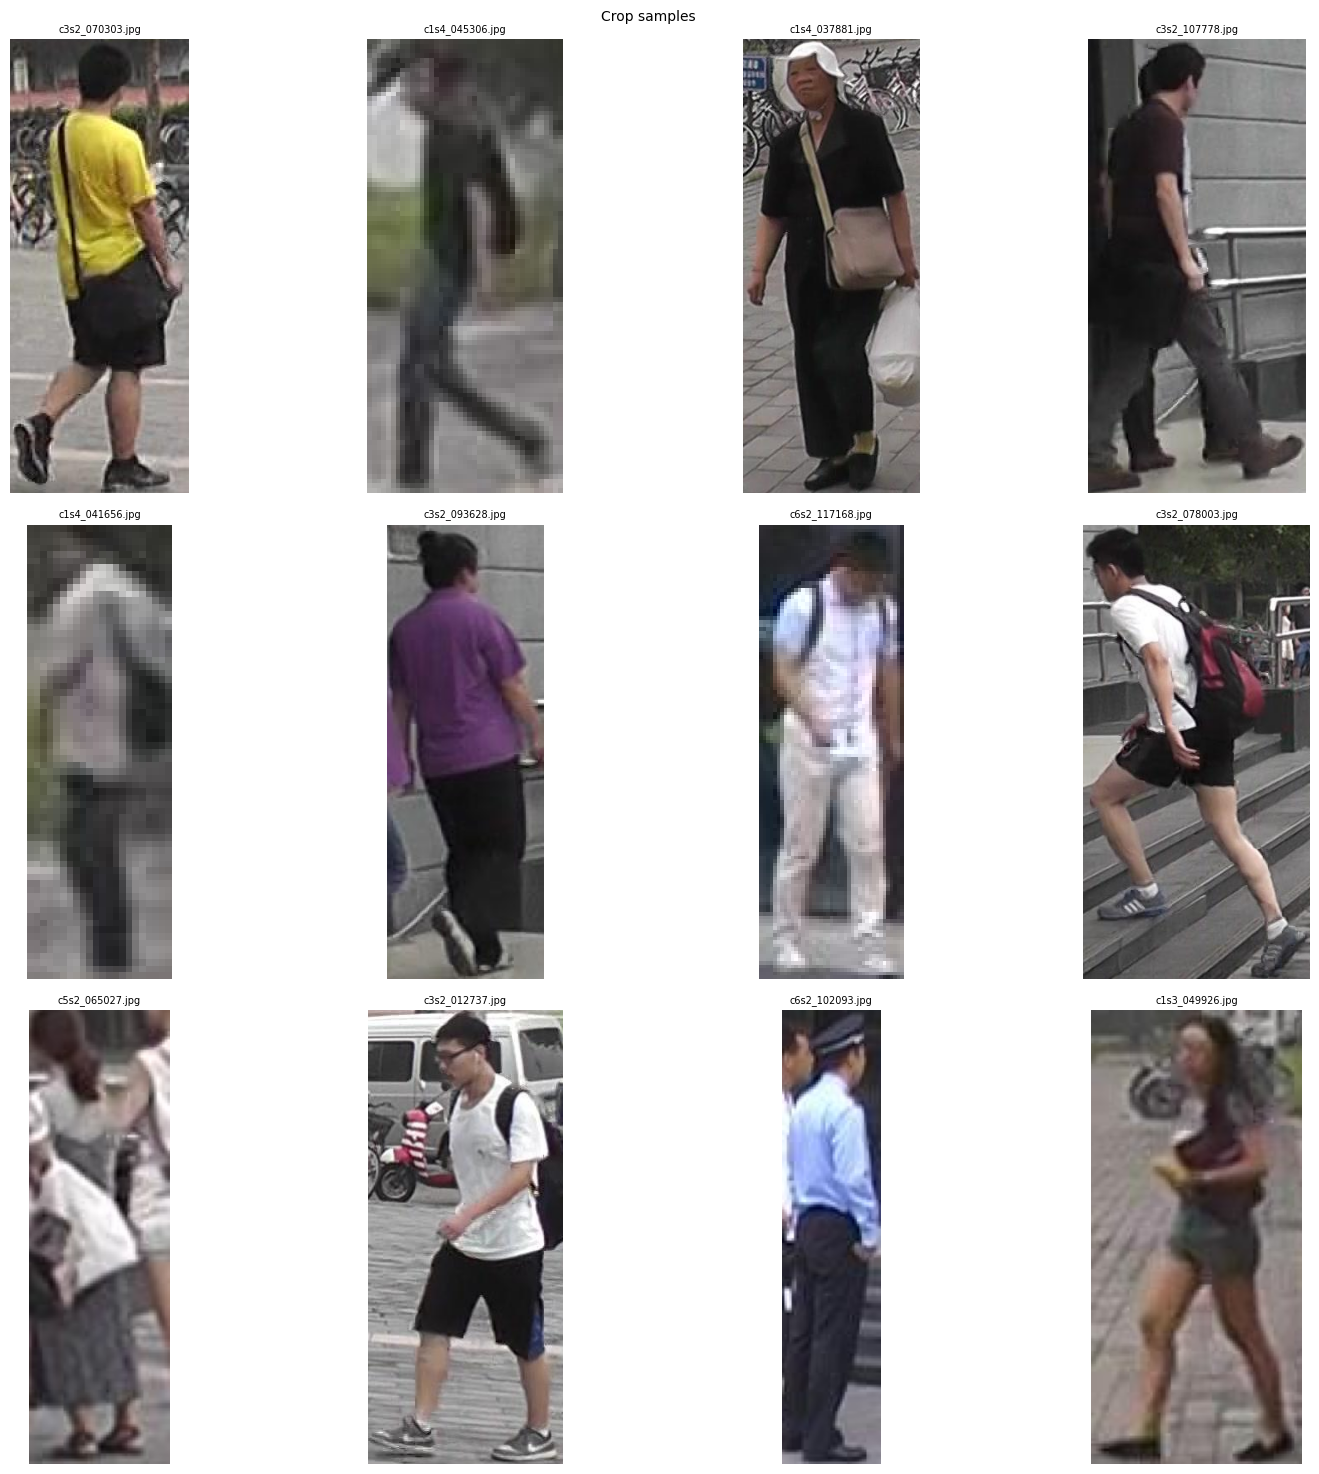

In [32]:
plot_crop_samples()

# 2. Re-Identification!

Second stage: fine-tune a DINOv3 encoder so its crop embeddings discriminate between individual identities.

## 2.1 Dataset

`PRWReIDDataset` serves the training crops from `dataset/query_box_train/`. The label is the person id parsed from the `NNN_` filename prefix, remapped to a contiguous `[0, num_ids)` range as the losses expect. Ids with fewer than 2 crops are dropped, since they cannot form a positive pair.

`split_train_val_ids` holds out 10% of the ids for validation.  
`build_collate_fn` applies the augmentations and the DINOv3 image processor when batching.

In [15]:
def _parse_pid_from_filename(name: str) -> int:
    # query boxes are "NNN_queryboxname.jpg"
    return int(name.split("_", 1)[0])


class PRWReIDDataset(Dataset):
    """
    Person crops for fine-tuning the feature extractor. Returns (PIL_image, label) tuples; 
    transforms + processor are applied in the collate_fn so we can vary them between train and eval splits.

    "id2label" maps raw PRW pid to contiguous [0, num_ids) label (required by arcface and friends).

    sources:
    - https://huggingface.co/docs/transformers/tasks/sequence_classification
    - google AI overview
    """

    def __init__(self, crops_dir: Path = TRAIN_CROPS_DIR,
                 keep_ids: Optional[set] = None,
                 min_crops_per_id: int = 2) -> None:
        all_files = sorted(p for p in crops_dir.iterdir() if p.suffix.lower() == ".jpg")
        pids = [_parse_pid_from_filename(p.name) for p in all_files]

        # drop ids with too few crops; cant form a valid pair
        counts = Counter(pids)
        kept = {pid for pid, c in counts.items() if c >= min_crops_per_id}
        if keep_ids is not None:
            kept &= set(keep_ids) # kept = kept ∩ keep_ids, useful for train and validation splits

        self.files = [f for f, pid in zip(all_files, pids) if pid in kept]
        self.pids = [pid for pid in pids if pid in kept]
        unique_pids = sorted(set(self.pids))
        self.id2label = {pid: i for i, pid in enumerate(unique_pids)}
        self.labels = [self.id2label[pid] for pid in self.pids]

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int):
        img = Image.open(self.files[idx]).convert("RGB")
        return img, self.labels[idx]


def split_train_val_ids(all_pids: list, val_frac: float = 0.1,
                        seed: int = 42, min_crops_per_id: int = 2) -> tuple:
    """Hold out val_frac of ids evalutaion. Returns set(train_ids), set(val_ids)"""
    counts = Counter(all_pids)
    eligible = sorted(pid for pid, c in counts.items() if c >= min_crops_per_id)
    rng = random.Random(seed)
    rng.shuffle(eligible)
    n_val = int(round(len(eligible) * val_frac))
    val_ids = set(eligible[:n_val])
    train_ids = set(eligible[n_val:])
    return train_ids, val_ids


def build_collate_fn(processor, transform=None): 
    """
    Builds collate function to group data into a batch with optional PIL transforms.
    HF processor returns (pixel_values, labels).
    """
    def _collate(batch):
        # transforms survive in this scope
        imgs = [b[0] if transform is None else transform(b[0]) for b in batch]
        labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
        pixel = processor(images=imgs, return_tensors="pt")["pixel_values"]
        return pixel, labels
    return _collate


## 2.2. Visual Encoder: DINO

The encoder backbone is **DINOv3-large (ViT-L/16)** (frozen up to the Nth layer), extended by a BNNeck-style projection head (BatchNorm → Linear → BatchNorm, [Luo et al. 2019](https://arxiv.org/abs/1903.07071)).   
Crops are encoded by mean-pooling the patch tokens (the CLS token is dropped); patch-level features capture fine-grained appearance detail better than the CLS token, which is optimized for category matching.  
Embeddings are L2-normalized so that a dot product equals cosine similarity.

In [16]:
class FineTunableDINOv3Encoder(nn.Module):
    """
    DINOv3 backbone with the last N transformer blocks unfrozen and a
    BNNeck-style projection head on top (BatchNorm -> Linear -> BatchNorm)
    
    sources:
    - https://arxiv.org/abs/1903.07071
    - https://huggingface.co/facebook/dinov3-vitl16-pretrain-lvd1689m
    - https://github.com/facebookresearch/dinov3
    - https://claude.ai/ (extraordinary for debugging)
    - google AI overview
    """

    def __init__(self,
                 model_name: str = "facebook/dinov3-vitl16-pretrain-lvd1689m",
                 embed_dim: int = 512,
                 unfreeze_last_n_blocks: int = 2,
                 batch_size: int = 32,
                 device: str = DEVICE) -> None:
        super().__init__()
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name)
        self.backbone_dim = self.backbone.config.hidden_size   # 1024 for ViT-L
        self.embed_dim = embed_dim
        self.unfreeze_n = unfreeze_last_n_blocks
        self.batch_size = batch_size
        self.device = device
        self.feat_dim = embed_dim
        self.name = "FineTunable DINOv3"

        # bag of tricks paper's projection head
        self.head = nn.Sequential(
            nn.BatchNorm1d(self.backbone_dim),
            nn.Linear(self.backbone_dim, embed_dim, bias=False),
            nn.BatchNorm1d(embed_dim),
        )
        self._set_freezing(unfreeze_last_n_blocks)
        self.to(device)

    def _transformer_blocks(self):
        return self.backbone.model.layer

    def _final_norm(self):
        return self.backbone.norm

    def _set_freezing(self, unfreeze_last_n_blocks: int) -> None:
        for p in self.backbone.parameters():
            p.requires_grad_(False)
        blocks = self._transformer_blocks()
        n = max(0, min(unfreeze_last_n_blocks, len(blocks))) # can't unfreeze more than the available blocks
        for blk in blocks[-n:] if n > 0 else []:
            for p in blk.parameters():
                p.requires_grad_(True)
        fn = self._final_norm()
        if fn is not None and n > 0:
            for p in fn.parameters():
                p.requires_grad_(True)

    def trainable_parameter_groups(self, lr_backbone: float, lr_head: float):
        # to list only trainable parameters to the optimizer, with different lr for bb and bn head
        backbone_params = [p for p in self.backbone.parameters() if p.requires_grad]
        head_params = list(self.head.parameters())
        groups = []
        if backbone_params:
            groups.append({"params": backbone_params, "lr": lr_backbone})
        groups.append({"params": head_params, "lr": lr_head})
        return groups

    def _pool(self, last_hidden_state: torch.Tensor) -> torch.Tensor:
        # mean over patch tokens
        # patch level features are way richer in details for comparison (outperforms cls token)
        # this pictures explains clearly why:
        # https://github.com/facebookresearch/dinov3#overview
        return last_hidden_state[:, 1:, :].mean(dim=1)

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """Training forward: returns raw [B, embed_dim] embeddings."""
        out = self.backbone(pixel_values=pixel_values)
        pooled = self._pool(out.last_hidden_state)
        return self.head(pooled)

    @torch.no_grad()
    def encode_images(self, images: list, disable_progress: bool = True) -> np.ndarray:
        """l2-normalized [N, embed_dim] visual features"""
        self.eval()
        all_feats = []
        for i in tqdm(range(0, len(images), self.batch_size),
                      desc="Visual features (queries)", unit="batch",
                      disable=disable_progress):
            batch = images[i : i + self.batch_size]
            inputs = self.processor(images=batch, return_tensors="pt").to(self.device)
            out = self.backbone(**inputs)
            pooled = self._pool(out.last_hidden_state)
            feats = self.head(pooled).cpu().float().numpy()
            all_feats.append(feats)
        feats = np.concatenate(all_feats, axis=0)
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)

    def encode_crops_from_paths(self, paths: list, desc: str = "FineTunable DINOv3", **kwargs) -> list:
        images = [Image.open(p).convert("RGB")
                  for p in tqdm(paths, desc=f"Loading ({desc})")]
        feats = self.encode_images(images, **kwargs)
        return [feats[i] for i in range(len(feats))]

    def save(self, path: str) -> None:
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        state = {
            "head": self.head.state_dict(),
            "backbone": {k: v for k, v in self.backbone.state_dict().items()
                         if self._param_was_trained(k)},
            "config": {
                "embed_dim": self.embed_dim,
                "unfreeze_last_n_blocks": self.unfreeze_n,
                "backbone_dim": self.backbone_dim,
            },
        }
        torch.save(state, path)

    def _param_was_trained(self, key: str) -> bool:
        # helps identify trained weights for a compact checkpoint
        n = self.unfreeze_n
        prefixes = []
        if n > 0:
            blocks = self._transformer_blocks()
            prefixes = [f"model.layer.{idx}."
                        for idx in range(len(blocks) - n, len(blocks))]
            prefixes.append(f"norm.")
        return any(key.startswith(p) for p in prefixes)

    def load(self, path: str, strict: bool = False) -> None:
        state = torch.load(path, map_location=self.device)
        self.head.load_state_dict(state["head"])

        # reapply freezing just to get the same model
        self.unfreeze_n = state["config"].get("unfreeze_last_n_blocks", self.unfreeze_n)
        self._set_freezing(self.unfreeze_n)

        # the checkpoint must contain the fine-tuned transformer blocks 
        # not just the final norm. it was not the case before :/
        saved_keys = list(state["backbone"].keys())
        n_block_keys = sum(k.startswith("model.layer") for k in saved_keys)
        if self.unfreeze_n > 0 and n_block_keys == 0:
            raise RuntimeError(
                f"Checkpoint {path} contains no transformer-block weights"
            )
        
        # https://discuss.pytorch.org/t/missing-keys-unexpected-keys-in-state-dict-when-loading-self-trained-model/22379
        missing, unexpected = self.backbone.load_state_dict(
            state["backbone"], strict=False
        )
        if unexpected:
            raise RuntimeError(f"load: unexpected backbone keys: {unexpected}")
        if strict and missing:
            raise RuntimeError(f"load mismatch: missing={missing}")


## 2.2 Metric Learning: ArcFace, TripletMargin, NT-Xent

`build_metric_loss` selects the metric-learning loss used to fine-tune the encoder, via [`pytorch-metric-learning`](https://github.com/KevinMusgrave/pytorch-metric-learning).

- **ArcFace**: classification-style angular-margin loss; carries a learnable per-class prototype matrix `W` whose parameters must be added to the optimizer.
- **TripletMargin**: pulls each anchor toward its hardest in-batch positive and pushes it away from its hardest negative. `BatchHardMiner` is used for mining.
- **NT-Xent**: contrastive loss; same-id crops in the batch act as positives against everything else.


In [17]:
def build_metric_loss(name: str, embed_dim: int, num_classes: int):
    """
    Builds a metric learning loss. Uses pytorch-metric-learning.
    Returns (loss_fn, miner_or_None, extra_optimizer_params).
    name: str
      'arcface' : ArcFaceLoss(num_classes, embed_dim), internal weights W.
      'triplet' : TripletMarginLoss + BatchHardMiner.
      'ntxent'  : NTXentLoss().
    sources:
    - https://github.com/KevinMusgrave/pytorch-metric-learning.
    - lecture slide: ML4CV_7_metric_learning.pdf
    """
    if name == "arcface":
        # arcface contains a learnable classification matrix W representing per-class prototypes;
        # W is l2-normalized so to compute cosine-similarity between an embedding and all the class prototypes.
        # tl;dr: its parameters must be passed to the optimizer!
        loss = losses.ArcFaceLoss(num_classes=num_classes,
                                  embedding_size=embed_dim).to(DEVICE)
        return loss, None, list(loss.parameters())
    if name == "triplet":
        loss = losses.TripletMarginLoss(margin=0.3)
        miner = miners.BatchHardMiner()
        return loss, miner, []
    if name == "ntxent":
        loss = losses.NTXentLoss()
        return loss, None, []
    raise ValueError(f"Unknown loss: {name}. Use arcface/triplet/ntxent.")


## 2.3 Evaluation Metric: Recall@1

`recall_at_1` measures how often the nearest neighbour of an embedding (excluding itself) shares its identity label. It is the validation signal used during fine-tuning: at the end of every epoch we encode the held-out crops and report this score over unseen ids.

In [18]:
def recall_at_1(embeddings: np.ndarray, labels: np.ndarray) -> float:
    """
    Recall@1 over l2-normalized embeddings.
    For each row, nearest neighbour, excluding self!!
    sources:
    - https://claude.ai/
    """
    sim = embeddings @ embeddings.T
    np.fill_diagonal(sim, -np.inf)
    nn = sim.argmax(axis=1)
    return float((labels[nn] == labels).mean())

## 2.4 Training Loop

`train_encoder` is the metric-learning training loop. The optimizer is `AdamW` with three parameter groups — backbone (small lr), BNNeck head (larger lr), and any loss-head parameters (ArcFace's `W`) — wrapped in a `CosineAnnealingLR` schedule.  
Batches come from `MPerClassSampler`, which guarantees `m` crops per id so the loss always has positive pairs to work with.  
Light augmentations (color jitter, occasional grayscale) are applied through the collate function.  
After each epoch the encoder is evaluated with `encode_val_set` + `recall_at_1`.

In [19]:
@torch.no_grad()
def encode_val_set(encoder, loader) -> tuple:
    encoder.eval()
    feats, labels = [], []
    for pixel, lbl in loader:
        pixel = pixel.to(encoder.device)
        emb = encoder(pixel)
        emb = F.normalize(emb, dim=1)
        feats.append(emb.cpu().float().numpy())
        labels.append(lbl.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labels, axis=0)


def train_encoder(encoder: nn.Module,
                  train_ds: Dataset,
                  val_ds: Dataset,
                  loss_name: str = "arcface",
                  epochs: int = 20,
                  batch_size: int = 32,
                  m_per_class: int = 2,
                  lr_backbone: float = 1e-4,
                  lr_head: float = 1e-3,
                  weight_decay: float = 1e-4,
                  checkpoint_path: str = "checkpoints/dinov3_finetune_forgot_to_name.pt",
                  show_loss_plot: bool = True) -> dict:
    """
    Main training loop with metric learning.
    Returns a history dict {'train_loss': [...], 'val_recall1': [...], 'best': float}.

    sources:
    - google AI overview
    - https://claude.ai/ (essential for debugging)
    """
    num_classes = len(set(train_ds.labels))
    loss_fn, miner, extra_params = build_metric_loss(
        loss_name, encoder.embed_dim, num_classes
    )

    # Param groups: backbone, head, loss head (if any).
    groups = encoder.trainable_parameter_groups(lr_backbone, lr_head)
    if extra_params:
        groups.append({"params": extra_params, "lr": lr_head})
    optim = AdamW(groups, weight_decay=weight_decay)

    train_aug = T.Compose([
        T.ColorJitter(0.2, 0.2, 0.2, 0.1),
        T.RandomGrayscale(p=0.05),
    ])
    eval_tx = None

    train_collate = build_collate_fn(encoder.processor, transform=train_aug)
    eval_collate = build_collate_fn(encoder.processor, transform=eval_tx)

    sampler = MPerClassSampler(
        train_ds.labels, m=m_per_class,
        length_before_new_iter=len(train_ds),
    )
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=sampler,
        collate_fn=train_collate, num_workers=2, drop_last=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        collate_fn=eval_collate, num_workers=2,
    )

    scheduler = CosineAnnealingLR(
        optim, T_max=max(1, epochs * len(train_loader))
    )

    history = {"train_loss": [], "val_recall1": [], "best": 0.0}

    for epoch in range(1, epochs + 1):
        encoder.train()
        running, seen = 0.0, 0
        pbar = tqdm(train_loader, desc=f"epoch {epoch}/{epochs}", unit="batch") # to show running loss in a cool way
        for pixel, labels in pbar:
            pixel = pixel.to(encoder.device, non_blocking=True)
            labels = labels.to(encoder.device, non_blocking=True)

            emb = encoder(pixel)
            if miner is not None:
                pairs = miner(emb, labels)
                loss = loss_fn(emb, labels, pairs)
            else:
                loss = loss_fn(emb, labels)

            optim.zero_grad(set_to_none=True)
            loss.backward()
            optim.step()
            scheduler.step()

            bs = pixel.size(0)
            running += loss.item() * bs
            seen += bs
            pbar.set_postfix(loss=f"{running/seen:.4f}")

        train_loss = running / seen 
        feats, labels = encode_val_set(encoder, val_loader)
        val_r1 = recall_at_1(feats, labels) # if len(feats) > 1 else float("nan")

        history["train_loss"].append(train_loss)
        history["val_recall1"].append(val_r1)
        print(f"[epoch {epoch:02d}] train_loss={train_loss:.4f} val_recall@1={val_r1:.4f}")

        if val_r1 > history["best"]:
            history["best"] = val_r1
            encoder.save(checkpoint_path)
            with open(Path(checkpoint_path).with_suffix(".json"), "w") as f:
                json.dump({
                    "loss_name": loss_name, "epoch": epoch,
                    "val_recall1": val_r1, "embed_dim": encoder.embed_dim,
                    "unfreeze_last_n_blocks": encoder.unfreeze_n,
                }, f, indent=2)
            print(f"  improved validation recall1, saved: {checkpoint_path}")
            
    # loss and recall curves only is specified; if full training set is used we train for only 1 epoch; plot looks horrible
    if show_loss_plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.plot(range(1, epochs+1), history["train_loss"], "o-")
        ax1.set(xlabel="epoch", ylabel="train loss", title=f"{loss_name} loss")
        ax2.plot(range(1, epochs+1), history["val_recall1"], "s-", color="tab:orange")
        ax2.set(xlabel="epoch", ylabel="val Recall@1", title="Held-out IDs")
        for ax in (ax1, ax2):
            ax.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    return history


In [30]:
# build full dataset first, then split into train/val by id
full_ds = PRWReIDDataset(TRAIN_CROPS_DIR, min_crops_per_id=2)
train_ids, val_ids = split_train_val_ids(full_ds.pids, val_frac=0.1, seed=42, min_crops_per_id=2)

train_ds = PRWReIDDataset(TRAIN_CROPS_DIR, keep_ids=train_ids, min_crops_per_id=2)
val_ds = PRWReIDDataset(TRAIN_CROPS_DIR, keep_ids=val_ids, min_crops_per_id=2)

print(f"train: {len(train_ds)} crops | {len(set(train_ds.labels))} ids")
print(f"val  : {len(val_ds)}   crops | {len(set(val_ds.labels))} ids")

train: 13205 crops | 433 ids
val  : 1690   crops | 48 ids


## 2.5 Training Re-ID configurations

The loop below trains one encoder per entry in `REID_CONFIGS`, saving its best checkpoint to `checkpoints/dinov3_finetune_{loss}.pt`.

In [21]:
best_recall, best_cfg = 0, None

for RUN_CONFIG, cfg in REID_CONFIGS.items(): # e.g.: "arcface", {"encoder": "dinov3", "loss": "arcface"}
    
    # hyperparams
    LOSS_NAME = cfg["loss"]
    ENCODER = cfg["encoder"]
    EMBED_DIM = cfg["embed_dim"]
    UNFREEZE_N = 4
    EPOCHS = 1
    TRAIN_BS = 32
    M_PER_CLASS = 2
    LR_BACKBONE = 1e-4
    LR_HEAD = 1e-3
    CHECKPOINT_PATH = f"checkpoints/dinov3_finetune_{RUN_CONFIG}.pt"

    print(f"\n{"=" * 80}")
    print(f"[Train] Config {RUN_CONFIG} | encoder={ENCODER}, loss={LOSS_NAME}")
    print("=" * 80)

    ft_encoder = FineTunableDINOv3Encoder(
        embed_dim=EMBED_DIM, unfreeze_last_n_blocks=UNFREEZE_N, device=DEVICE,
    )

    history = train_encoder(
        ft_encoder, train_ds, val_ds,
        loss_name=LOSS_NAME, epochs=EPOCHS, batch_size=TRAIN_BS,
        m_per_class=M_PER_CLASS, lr_backbone=LR_BACKBONE, lr_head=LR_HEAD,
        checkpoint_path=CHECKPOINT_PATH, show_loss_plot=False
    )

    if history["best"] > best_recall:
        best_recall = history["best"]
        best_cfg = RUN_CONFIG

print(f"Best val Recall@1: {best_recall:.4f}")
print(f"Configuration:     {best_cfg}")


[Train] Config arcface | encoder=dinov3, loss=arcface


epoch 1/1: 100%|██████████| 405/405 [01:29<00:00,  4.53batch/s, loss=25.6565]


[epoch 01] train_loss=25.6565 val_recall@1=0.9893
  improved validation recall1, saved: checkpoints/dinov3_finetune_arcface.pt

[Train] Config triplet | encoder=dinov3, loss=triplet


epoch 1/1: 100%|██████████| 405/405 [01:29<00:00,  4.50batch/s, loss=0.1978]


[epoch 01] train_loss=0.1978 val_recall@1=0.9852
  improved validation recall1, saved: checkpoints/dinov3_finetune_triplet.pt

[Train] Config ntxent | encoder=dinov3, loss=ntxent


epoch 1/1: 100%|██████████| 405/405 [01:29<00:00,  4.52batch/s, loss=0.3463]


[epoch 01] train_loss=0.3463 val_recall@1=0.9893
  improved validation recall1, saved: checkpoints/dinov3_finetune_ntxent.pt
Best val Recall@1: 0.9893
Configuration:     arcface


## 2.6 Gallery visual features

Each detected person box is cropped from its gallery frame and encoded with the fine-tuned DINOv3, producing one `[n_det, embed_dim]` array of L2-normalized features per frame (empty for frames with no detections). Results are cached per configuration.

In [22]:
def _crop_persons(frame: Image.Image, dets: np.ndarray) -> list:
    """Crop detected bounding boxes from a PIL frame, clipping to image bounds"""
    W, H = frame.size
    crops = []
    for x1, y1, x2, y2, _ in dets:
        x1c, y1c = max(0, int(x1)), max(0, int(y1))
        x2c, y2c = min(W, int(x2)), min(H, int(y2))
        crops.append(frame.crop((x1c, y1c, x2c, y2c)))
    return crops


def run_gallery_visual_features(gallery_dataset: PRWDetectorDataset, gallery_dets: list,
                                encoder: FineTunableDINOv3Encoder, cache_path: Path,
                                force: bool = False) -> list:
    """
    Extract DINOv3 pooled patch features for every detected person crop.
    Returns list of [n_det, embed_dim] l2-normalized float32 arrays; [0, D] for empty frames.
    """
    if cache_path.exists() and not force:
        print(f"Loading visual features from cache: {cache_path}")
        return list(np.load(str(cache_path), allow_pickle=True))

    D = encoder.feat_dim
    gallery_feats = []
    for i in tqdm(range(len(gallery_dataset)), desc="Visual features (gallery)", unit="frame"):
        dets = gallery_dets[i]
        if dets.shape[0] == 0:
            gallery_feats.append(np.zeros((0, D), dtype=np.float32))
            continue
        frame = Image.open(gallery_dataset.get_image_path(i)).convert("RGB")
        crops = _crop_persons(frame, dets)
        gallery_feats.append(encoder.encode_images(crops)) # [n_det, D]

    arr = np.empty(len(gallery_feats), dtype=object)
    for i, f in enumerate(gallery_feats):
        arr[i] = f
    np.save(str(cache_path), arr)
    print(f"Saved visual features: {cache_path}")
    return list(arr)

## 2.7 Query visual features

Query images are already cropped to a single person, so no detection is needed. They are encoded with the same fine-tuned encoder, yielding one embedding per query that is then matched against the gallery features.

In [23]:
def run_query_features(query_dataset: PRWDetectorDataset, encoder: FineTunableDINOv3Encoder,
                       vis_cache: Path, force: bool = False) -> list:
    """
    Extract DINOv3 pooled patch features for all query crops.
    Returns list of [embed_dim,] l2-normalized float32 arrays.
    """
    if vis_cache.exists() and not force:
        print(f"Loading query visual features from cache: {vis_cache}")
        vis_feats = np.load(str(vis_cache))
    else:
        paths = [query_dataset.get_image_path(i) for i in range(len(query_dataset))]
        vis_list = encoder.encode_crops_from_paths(paths, desc=f"{encoder.name} (queries)", disable_progress=False)
        vis_feats = np.stack(vis_list, axis=0)
        np.save(str(vis_cache), vis_feats)
        print(f"Saved query visual features: {vis_cache}")

    return [vis_feats[i] for i in range(len(vis_feats))]

# 3. Detection + Re-Identification!

Final stage: assemble the full pipeline. For every entry in `PERSONSEARCH_CONFIGS` we run the detector on the test gallery, encode each detected crop with the fine-tuned DINOv3 from its checkpoint, and score the resulting person search with `eval_search_prw`.

## 3.1 Evaluation

`eval_search_prw` scores person-search performance:
- ranks every gallery detection by cosine similarity to the query embedding;
- counts a detection as correct when its IoU with the ground-truth box clears the threshold;
- computes per-query Average Precision, scaled by detection recall so missed detections are penalized;
- returns **mAP** and **top-1 accuracy**.

The loop below evaluates every entry in `PERSONSEARCH_CONFIGS`: it loads the matching detector and fine-tuned checkpoint, computes gallery and query features, and saves the metrics per config.

In [24]:
FORCE_RERUN_VISUAL_FEATURES = True
query_dataset = build_query_dataset(DATASET_ROOT, split="test")
gallery_dataset = build_gallery_dataset(DATASET_ROOT, split="test")

eval_results = dict()

for RUN_CONFIG, cfg in PERSONSEARCH_CONFIGS.items(): # e.g.: "A": {"detector": "yolo12", "threshold": 0.3, "encoder": "dinov3",  "loss": "arcface"}

    DETECTOR = cfg["detector"]
    DET_THRESH = cfg["threshold"]
    ENCODER = cfg["encoder"]
    EMBED_DIM = cfg["embed_dim"]
    LOSS_NAME = cfg["loss"]

    print(f"\n{"=" * 80}")
    print(f"[Test] Config {RUN_CONFIG} | detector={DETECTOR}, det_thresh={DET_THRESH}, encoder={ENCODER}, loss={LOSS_NAME}")
    print("=" * 80)

    # cache paths to avoid reruns
    DETS_CACHE = CACHE_DIR / f"gallery_dets_{DETECTOR}.npy" # we use detector for caching detections; so can be reusable
    VIS_CACHE = CACHE_DIR / f"gallery_vis_{RUN_CONFIG}.npy" # by different configurations with same detector
    Q_VIS_CACHE = CACHE_DIR / f"query_vis_{RUN_CONFIG}.npy" # visual features are computed on top detections; can't be shared by configurations with same visual encoder

    # load detector
    detector = build_detector(cfg)
    gallery_dets = run_gallery_detection(gallery_dataset, detector, DETS_CACHE)

    # load fine-tuned visual encoder
    CHECKPOINT_PATH = f"checkpoints/dinov3_finetune_{LOSS_NAME}.pt" # checkpoint are indexed by the loss
    ft_encoder = FineTunableDINOv3Encoder(embed_dim=EMBED_DIM,device=DEVICE)
    ft_encoder.load(CHECKPOINT_PATH)

    # compute visual features
    gallery_feats = run_gallery_visual_features(
        gallery_dataset, gallery_dets, ft_encoder, VIS_CACHE, force=FORCE_RERUN_VISUAL_FEATURES
    )

    query_box_feats = run_query_features(
        query_dataset, encoder=ft_encoder, vis_cache=Q_VIS_CACHE, force=FORCE_RERUN_VISUAL_FEATURES
    )

    # final evaluation
    eval_results[RUN_CONFIG] = eval_search_prw(
        gallery_dataset=gallery_dataset,
        query_dataset=query_dataset,
        gallery_dets=gallery_dets,
        gallery_feats=gallery_feats,
        query_box_feats=query_box_feats,
        det_thresh=DET_THRESH,
    )

    # save metrics in json
    out = {k: v.tolist() if isinstance(v, np.ndarray) else v
        for k, v in eval_results[RUN_CONFIG].items() if k != "results"}
    results_path = CACHE_DIR / f"results_{RUN_CONFIG}.json"
    with open(results_path, "w") as f:
        json.dump(out, f, indent=2)
    print(f"\nResults saved: {results_path}")

Loading gallery annotations: 100%|██████████| 6112/6112 [00:00<00:00, 10878.16it/s]



[Test] Config A | detector=yolo12, det_thresh=0.3, encoder=dinov3, loss=arcface


Detecting gallery:   0%|          | 13/6112 [00:00<01:36, 63.03frame/s]

Detecting gallery: 100%|██████████| 6112/6112 [01:12<00:00, 83.77frame/s] 


Saved detections: finetune_cache/gallery_dets_yolo12.npy


...

Saved query visual features: finetune_cache/query_vis_E.npy
recall rate: 1.0
search ranking:
  mAP = 57.85%
  top- 1 = 83.96%

Results saved: finetune_cache/results_E.json

[Test] Config F | detector=rfdetr, det_thresh=0.5, encoder=dinov3, loss=ntxent
[2026-05-20 20:45:00] [INFO] rf-detr - File /home/leonardo/github/person-search/detectors/rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-20 20:45:00] [INFO] rf-detr - File /home/leonardo/github/person-search/detectors/rf-detr-base.pth already exists with correct MD5 hash.
Loading detections from cache: finetune_cache/gallery_dets_rfdetr.npy


Visual features (gallery): 100%|██████████| 6112/6112 [03:11<00:00, 31.91frame/s]


Saved visual features: finetune_cache/gallery_vis_F.npy


Visual features (queries): 100%|██████████| 65/65 [00:11<00:00,  5.76batch/s]


Saved query visual features: finetune_cache/query_vis_F.npy
recall rate: 1.0
search ranking:
  mAP = 57.68%
  top- 1 = 85.61%

Results saved: finetune_cache/results_F.json


## 3.2 Qualitative Visualization

Query crops are shown next to their top-k gallery retrievals. A green box marks a correct match (IoU ≥ threshold), a red box marks a wrong one.

In [25]:
def visualize_query_results(results: dict, n_queries: int = 3, top_k: int = 5) -> None:
    """
    Visualize graphically person search ranking.
    
    sources:
    - https://claude.ai
    """
    img_root  = results['image_root']
    sample    = random.sample(results['results'], n_queries)
    ann_by_name = {a['img_name']: i for i, a in enumerate(query_dataset.annotations)}

    for entry in sample:
        fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 2), 4))

        q_idx = ann_by_name.get(entry['query_img'], 0)
        axes[0].imshow(Image.open(query_dataset.get_image_path(q_idx)))
        axes[0].set_title(f'Query\n{entry["query_img"]}', fontsize=7)
        axes[0].axis('off')

        for k, hit in enumerate(entry['gallery'][:top_k]):
            frame = Image.open(os.path.join(img_root, hit['img']))
            axes[k + 1].imshow(frame)
            x1, y1, x2, y2 = hit['roi'][:4]
            color = 'lime' if hit['correct'] else 'red'
            axes[k + 1].add_patch(
                patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color, facecolor='none',
                )
            )
            axes[k + 1].set_title(
                f'#{k+1} {"\u2713" if hit["correct"] else "\u2717"}\n{hit["score"]:.3f}',
                fontsize=8, color=color,
            )
            axes[k + 1].axis('off')

        plt.suptitle(f'Query source: {entry["query_img"]}', fontsize=9)
        plt.tight_layout()
        plt.show()

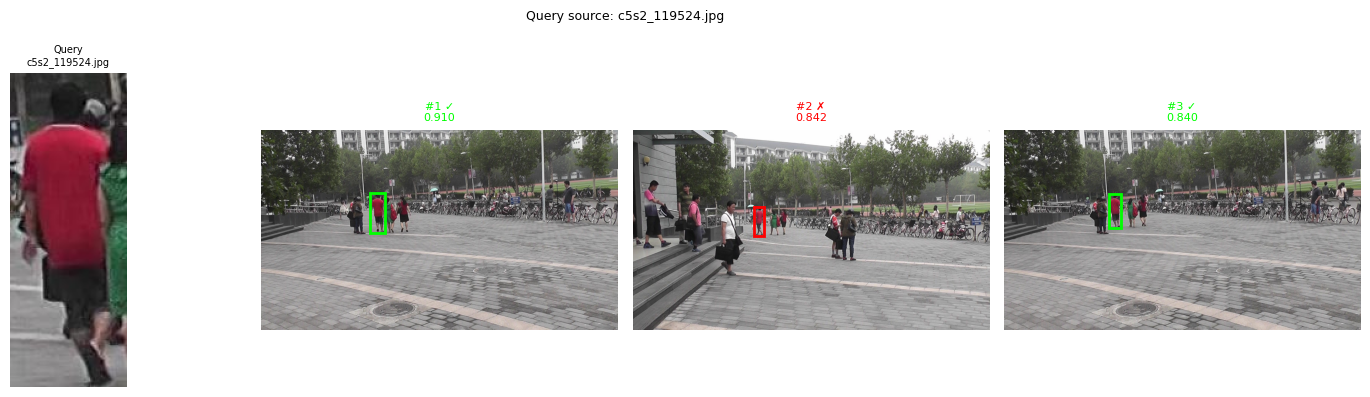

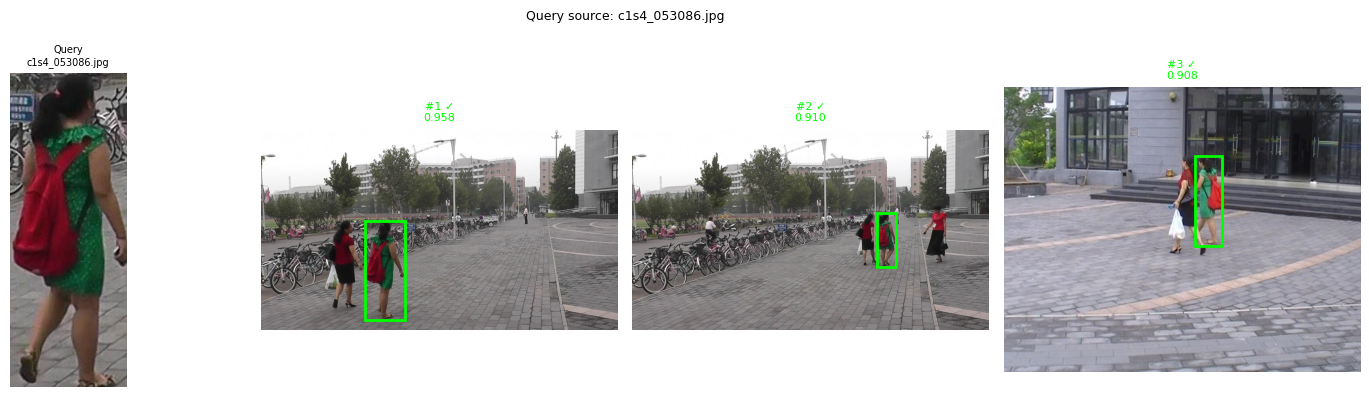

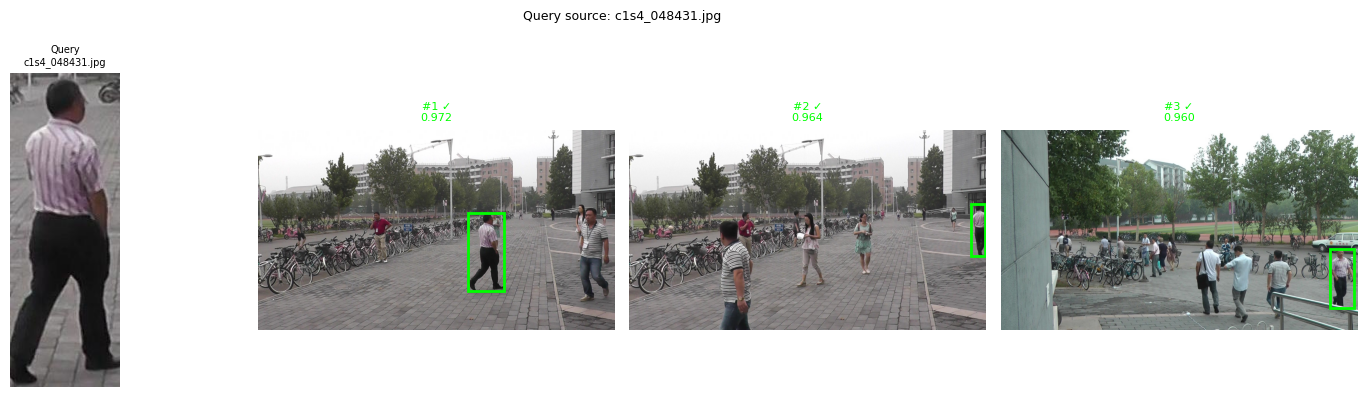

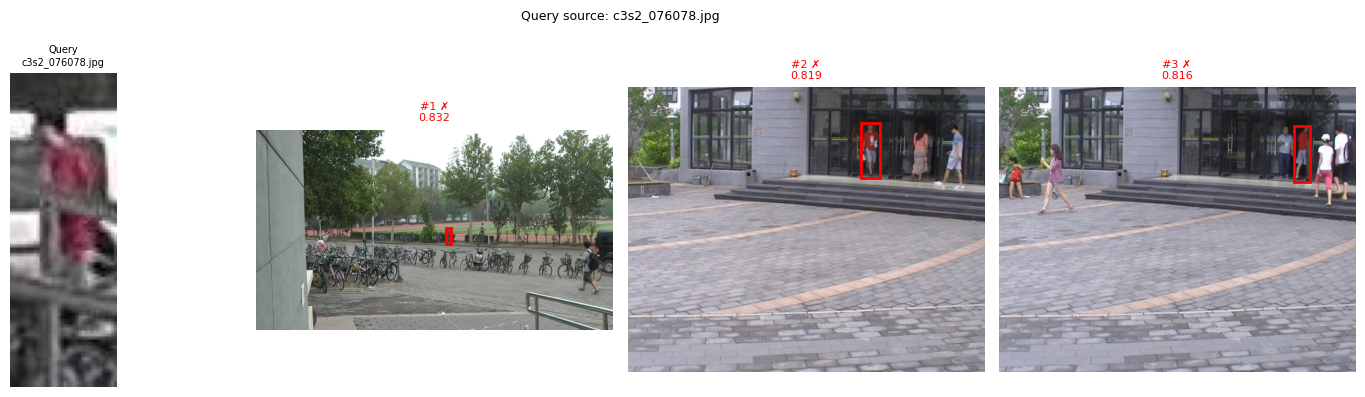

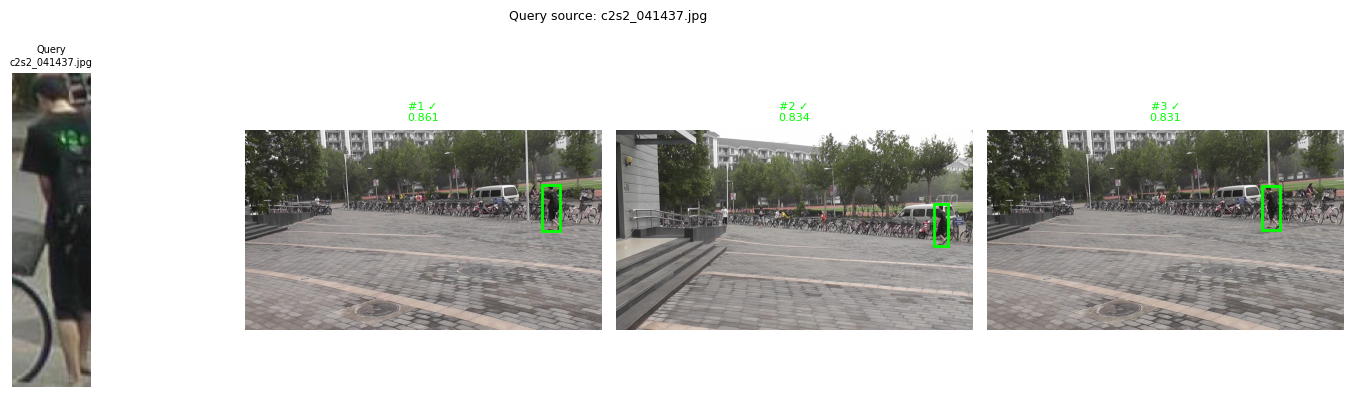

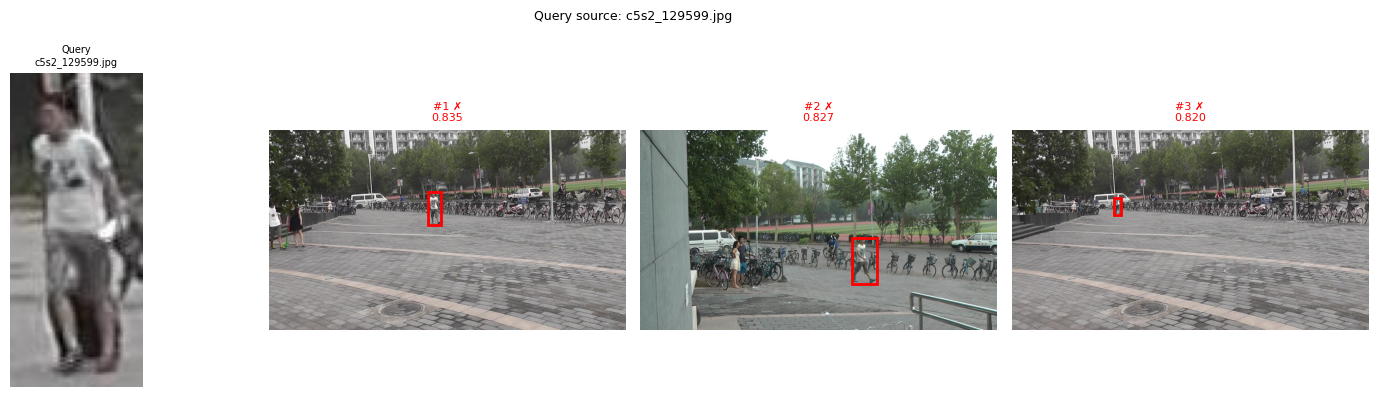

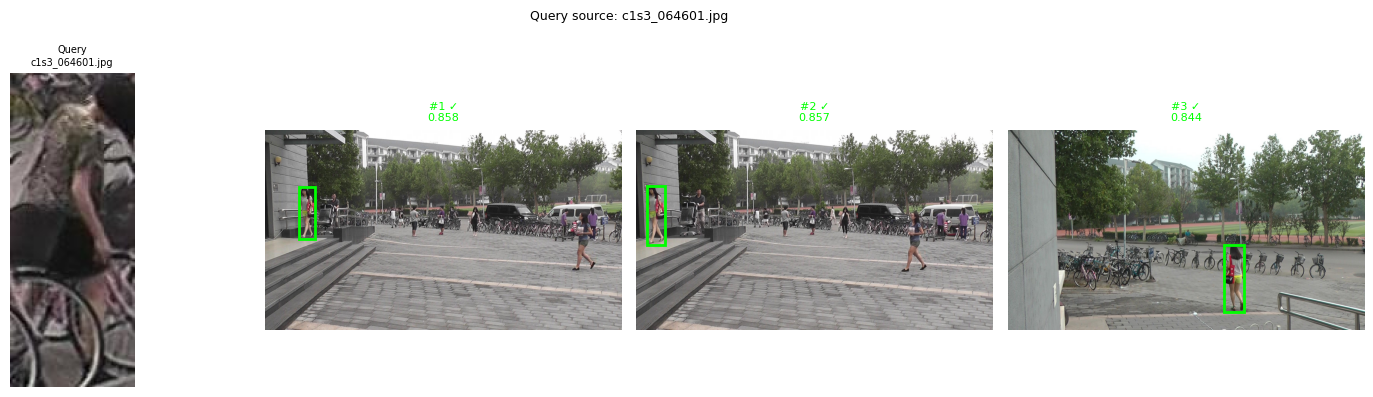

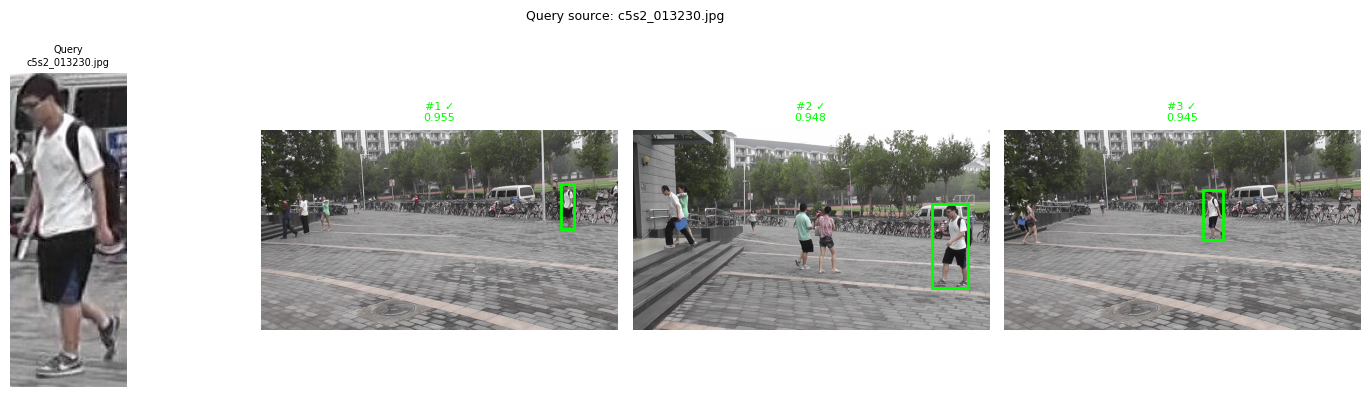

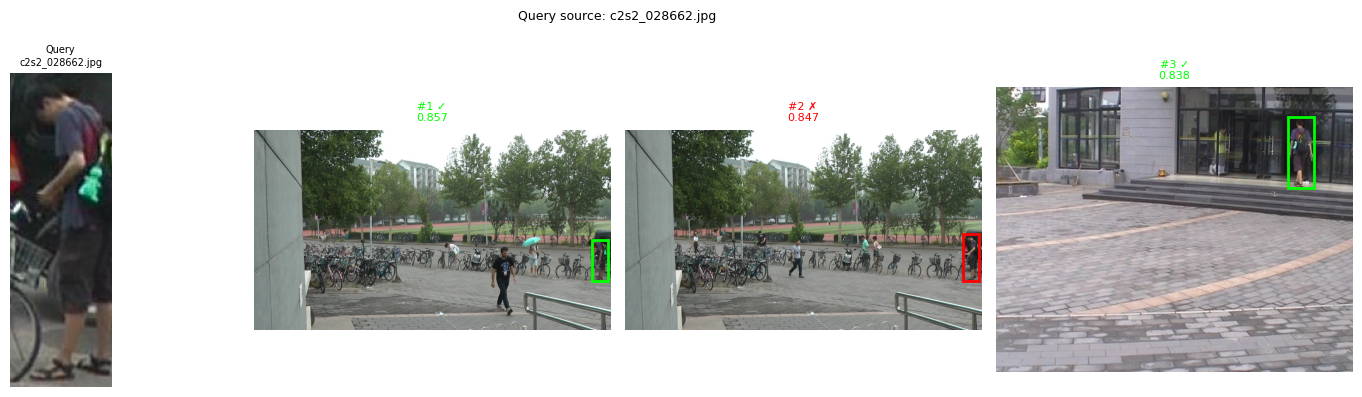

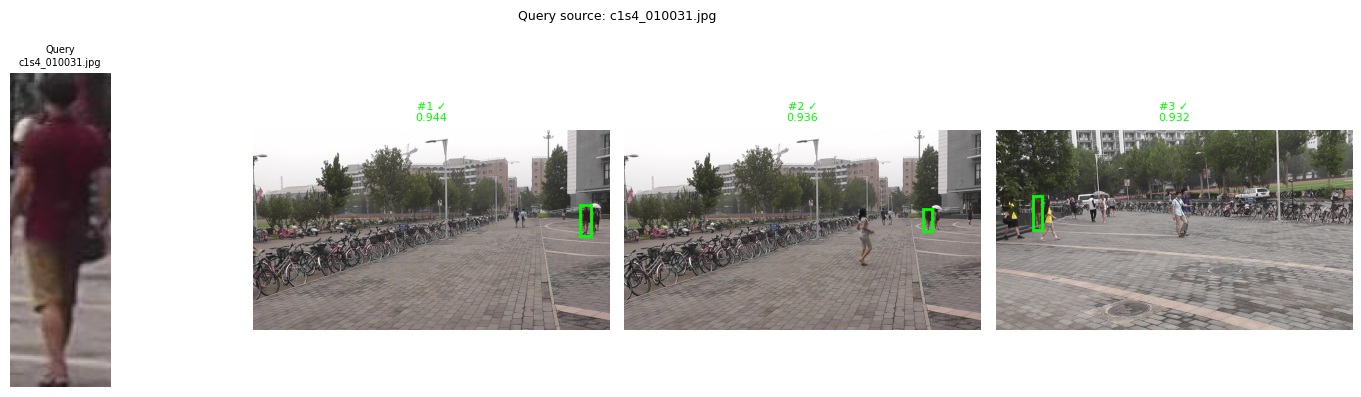

In [38]:
visualize_query_results(eval_results["C"], n_queries=10, top_k=3)